> ### Inferencia y Filtro RAD-ALERT
> Este cuaderno documenta la concatenación y el filtrado de los reportes radiológicos mediante el modelo pre-entrenado RAD-ALERT.
>* **Objetivo:** Aislar únicamente los casos clínicamente críticos. Sobre este subconjunto de datos se entrenan y evalúan los modelos de diagnóstico multietiqueta del PDG.
> * **Consideración de RAD-ALERT:** La ejecución activa de este notebook requiere los pesos locales de RAD-ALERT (`config.json`, `tokenizer` > y `model.safetensors`).

In [39]:
# Dependencias adicionales requeridas para ejecutar la inferencia con RAD-ALERT.
# Si ya están instaladas en tu entorno, puedes saltar esta celda.
# %pip install --upgrade --no-cache-dir "tokenizers==0.20.3" "transformers==4.46.3" Unidecode

In [28]:
# ─── Librerías ─────────────────────────────────────────────────
import pandas as pd
import re
import warnings
from pathlib import Path
from unidecode import unidecode
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# ─── Variables de entorno ────────────────────────────────────────
from dotenv import load_dotenv
import os

load_dotenv()
DATA_DIR   = os.getenv('DATA_DIR',   '../data')
MODELS_DIR = os.getenv('MODELS_DIR', '../models/rad-alert')

warnings.filterwarnings('ignore')
print(f'DATA_DIR   → {DATA_DIR}')
print(f'MODELS_DIR → {MODELS_DIR}')

# Visualización
import matplotlib.pyplot as plt
from wordcloud import WordCloud


DATA_DIR   → ../data
MODELS_DIR → ../models/rad-alert


### 1. Carga del dataset


In [40]:
# Cargar el dataset limpio generado en el notebook 0.0
df = pd.read_excel(f'{DATA_DIR}/data_cleaned.xlsx')
print(f'Registros cargados: {len(df)}')
df.head(2)


Registros cargados: 3977


,Fecha(dd/mm/yyyy),Modalidad,Estudio,Técnica,Datos Clínicos,Hallazgos,Opinión,Reporte estructurado,Estudio Complementario Sugerido,Hallazgo Crítico,Estudio Normal
0,2019-01-01 00:00:00,CT,tomografia computada de craneo simple,"en equipo multidetector, se realizan cortes ax...",cefalea intensa con signos de alarma. descarta...,área de hipodensidad en la sustancia blanca su...,hipodensidad descrita en el lóbulo frontal izq...,0,1,0,0
1,2019-01-01 00:00:00,CT,tomografia computada de craneo simple,se realizan cortes axiales desde fosa posterio...,tce. cefalea y emesis persistente.,signos de sangrado. hematoma subdural: no. hem...,estudio sin evidencia de lesiones traumáticas ...,1,0,0,0


### 2. Preparación del input

El texto de `Hallazgos` y `Opinión` ya fue normalizado en el notebook `0.0`.
Aquí simplemente se concatenan ambas columnas para construir el input del modelo.


In [30]:
# El tokenizador de RAD-ALERT maneja su propia normalización interna.
# Solo concatenamos las columnas de texto ya limpias desde data_cleaned.xlsx y usamos el nombre esperado 'texto_normalizado'.
df['texto_normalizado'] = df['Hallazgos'].fillna('') + ' ' + df['Opinión'].fillna('')
print(f'Input preparado para {len(df)} registros.')

# Mostrar un ejemplo del texto concatenado resultante
print('\nEjemplo del primer registro concatenado:')
print(df['texto_normalizado'].iloc[0][:300] + '...')


Input preparado para 3977 registros.

Ejemplo del primer registro concatenado:
área de hipodensidad en la sustancia blanca subcortical del lóbulo frontal izquierdo. no se observan masas ni desviación de las estructuras de la línea media. el sistema ventricular no muestra alteraciones. no hay evidencia de hemorragia intracraneana ni colecciones extra-axiales. no se observan lín...


### 3. Carga del modelo RAD-ALERT

Se carga el clasificador desde la ruta local definida en `MODELS_DIR`.
Si el modelo no está disponible, esta celda lanzará un error claro.


In [31]:
# Resolución de la ruta del modelo RAD-ALERT.
# Prioridad: variable MODELS_DIR del .env > rutas candidatas relativas.
# Si ambos repositorios (PDG-Diagnostico-Clinico y RAD-ALERT) están en la misma carpeta padre,
# la detección automática funcionará sin configuración adicional.

candidate_paths = [
    Path(MODELS_DIR),                       # Configurado por el usuario en .env
    Path('../../RAD-ALERT/model'),           # Estructura por defecto: PDG II/RAD-ALERT/model
    Path('../RAD-ALERT/model'),              # Alternativa: repositorios al mismo nivel
    Path('./models/rad-alert'),              # Modelo copiado localmente
]

model_path = next((p for p in candidate_paths if p.exists()), None)

if model_path is None:
    raise FileNotFoundError(
        "\n\n[ERROR DE REPRODUCIBILIDAD]\n"
        "No se encontro la carpeta con los pesos del modelo RAD-ALERT en ninguna ruta candidata.\n\n"
        "Rutas verificadas:\n"
        + '\n'.join(f'  - {p.resolve()}' for p in candidate_paths) +
        "\n\nOpciones:\n"
        "  1. Clona o descarga el repositorio RAD-ALERT en la carpeta hermana de PDG-Diagnostico-Clinico.\n"
        "  2. O configura la variable MODELS_DIR en un archivo .env en la raiz del proyecto.\n"
        "  3. Si no necesitas re-etiquetar, omite este notebook: el dataset listo esta en 'data/data_cleaned.xlsx'."
    )

print(f'Modelo encontrado en: {model_path.resolve()}')

tokenizer = AutoTokenizer.from_pretrained(str(model_path), local_files_only=True)
model = AutoModelForSequenceClassification.from_pretrained(str(model_path), local_files_only=True)

device = torch.device('cpu')
model.to(device)
model.eval()
print(f'Modelo cargado correctamente en {device}.')


Modelo encontrado en: C:\Users\nsp1324\Documents\PDG II\RAD-ALERT\model
Modelo cargado correctamente en cpu.


### 4. Inferencia sobre el dataset


In [32]:
# Función para predecir
def predict_critical(text):
    if not text.strip():
        return "No crítico", 0.0
        
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512, padding=True).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
        # Ajusta el índice (1 o 0) según qué clase represente 'Crítico' en tu modelo
        prob_critico = probs[0][1].item() 
        
    pred = "Crítico" if prob_critico >= 0.5 else "No crítico"
    return pred, prob_critico

# Aplicar a todo el dataset
# Descomenta las siguientes líneas cuando el modelo esté configurado:
print("Iniciando inferencia...")
df['rad_prediccion'], df['rad_score'] = zip(*df['texto_normalizado'].apply(predict_critical))
print(df['rad_prediccion'].value_counts())

Iniciando inferencia...
rad_prediccion
No crítico    2947
Crítico       1030
Name: count, dtype: int64


### 5. Filtrado y exportación


In [33]:
# Filtrar y Exportar
# Descomenta esto después de ejecutar la inferencia exitosamente.

df_criticos = df[df['rad_prediccion'] == 'Crítico'].copy()
print(f"Total de registros Críticos identificados por RAD-ALERT: {len(df_criticos)}")

# Guardar el dataset final como rad_criticos.xlsx
df_criticos.to_excel('../data/rad_criticos.xlsx', index=False)
print("Exportado exitosamente a '../data/rad_criticos.xlsx'")


Total de registros Críticos identificados por RAD-ALERT: 1030
Exportado exitosamente a '../data/rad_criticos.xlsx'


### 6. Análisis visual de los textos clasificados


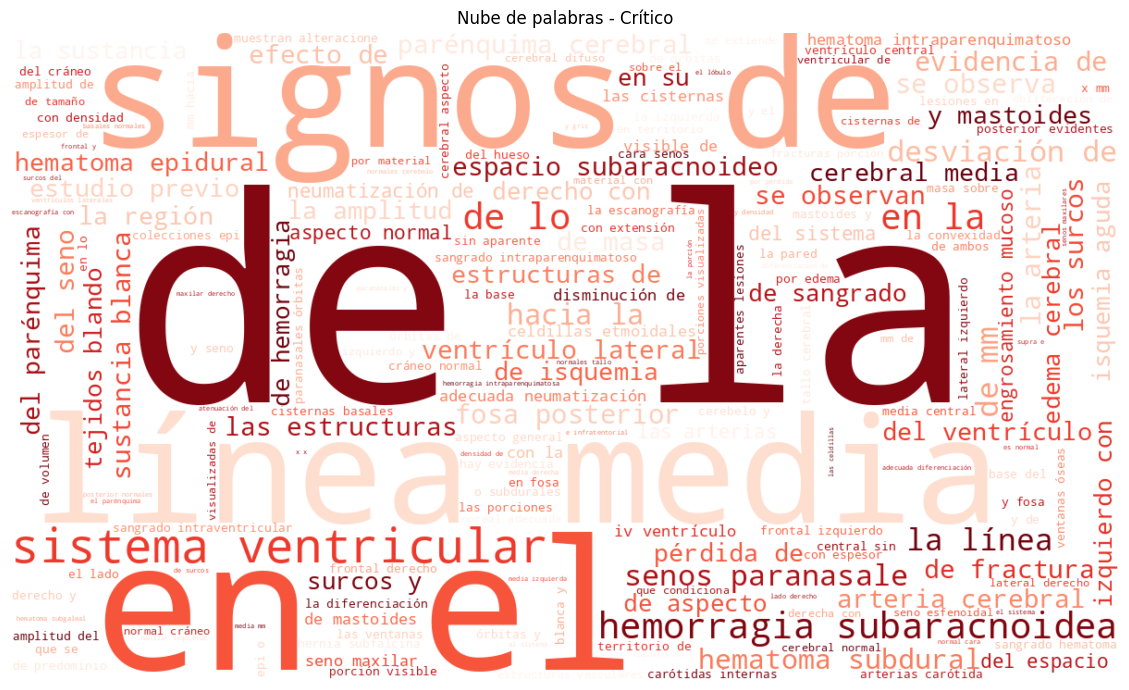

In [37]:
excel_path = '../data/rad_criticos.xlsx'
df = pd.read_excel(excel_path)

missing = {'texto_normalizado', 'rad_prediccion'} - set(df.columns)
if missing:
    raise ValueError(f'Missing columns: {missing}')

df['texto_normalizado'] = df['texto_normalizado'].fillna('').astype(str)

critical_text = ' '.join(
    df.loc[
        df['rad_prediccion'].astype(str).str.strip().str.lower() == 'crítico',
        'texto_normalizado'
    ]
)

if not critical_text.strip():
    critical_text = 'no_data'

wordcloud = WordCloud(
    width=1200,
    height=700,
    background_color='white',
    colormap='Reds'
).generate(critical_text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de palabras - Crítico')

plt.tight_layout()
plt.show()